# 2. PSF modeling and subtraction

In this notebook, we demonstrate the PSF modeling and subtraction tools in coronspec_tools. We're going to use the offset files with the incidental source in the slit.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

In [3]:
import matplotlib as mpl
from matplotlib import pyplot as plt

In [4]:
from coronspec_tools import utils as ctutils
from coronspec_tools import misc as ctmisc

In [5]:
from astropy import units

## List and organize the data files

I like to use a Pandas dataframe to organize my data files by metadata. Since all data files of the same type (e.g. sx1, sx2, flt, et cetera) have the same header keywords, they fit neatly into a dataframe format where the columns represent the keyword value and each row is a separate file. `coronspec_tools.utils` has some functions for setting this up.

In [12]:
# First, let's list all the data files available. Set your path as appropriate.
data_files = sorted(Path("../../data/HST/").glob("of*/*fits"))

In [13]:
data_files

[PosixPath('../../data/HST/of0i01010/of0i01010_asn.fits'),
 PosixPath('../../data/HST/of0i01010/of0i01010_drj.fits'),
 PosixPath('../../data/HST/of0i01010/of0i01010_flt.fits'),
 PosixPath('../../data/HST/of0i01010/of0i01010_sx1.fits'),
 PosixPath('../../data/HST/of0i01010/of0i01010_sx2.fits'),
 PosixPath('../../data/HST/of0i01020/of0i01020_asn.fits'),
 PosixPath('../../data/HST/of0i01020/of0i01020_drj.fits'),
 PosixPath('../../data/HST/of0i01020/of0i01020_flt.fits'),
 PosixPath('../../data/HST/of0i01020/of0i01020_sx2.fits'),
 PosixPath('../../data/HST/of0i01030/of0i01030_asn.fits'),
 PosixPath('../../data/HST/of0i01030/of0i01030_drj.fits'),
 PosixPath('../../data/HST/of0i01030/of0i01030_flt.fits'),
 PosixPath('../../data/HST/of0i01030/of0i01030_sx2.fits'),
 PosixPath('../../data/HST/of0i01040/of0i01040_asn.fits'),
 PosixPath('../../data/HST/of0i01040/of0i01040_flt.fits'),
 PosixPath('../../data/HST/of0i02010/of0i02010_asn.fits'),
 PosixPath('../../data/HST/of0i02010/of0i02010_drj.fits'

In [14]:
# for each file type, let's make a separate "file manager" dataframe using utils.organize_files_by_header(list_of_files)
file_managers = {}
for f in data_files:
    ftype = f.stem.split("_")[1]
    if ftype not in file_managers.keys():
        file_managers[ftype] = []
    file_managers[ftype].append(f)
for ft in file_managers:
    file_managers[ft] = ctutils.organize_files_by_header(file_managers[ft])

In [15]:
# we need the sx1 file, the unocculted exposure, and the occulted exposure. Looking at the Data Spreadsheet, these are:
sx1_rootname = 'OF0I02010'.lower()
unocc_rootname = 'OF0I02010'.lower()
occ_rootname = 'OF0I02020'.lower()

# the sx1 file is in the sx1 file manager:
sx1_file = file_managers['sx1'].set_index("ROOTNAME").loc[sx1_rootname]['filepath']
# we're going to use the _un_rectified 2-D spectral images
unocc_file = file_managers['drj'].set_index("ROOTNAME").loc[unocc_rootname]['filepath']
occ_file = file_managers['drj'].set_index("ROOTNAME").loc[occ_rootname]['filepath']

In [25]:
from coronspec_tools import observing_sequence
obs = observing_sequence.ObsSeq(
    sx1_file=sx1_file,
    unocc_file=unocc_file,
    occ_file=occ_file,
    trace_width = 11, # cut out a stamp of this width in rows around the unocculted trace
    occ_stamp_width = 101, # cut a stamp of this width in rows around the occulted star position
    median_clean = 10, # apply a median filter of 2x this width in columns to smooth bad pixels
    contrast = True, # if True, divide by the unocculted spectrum to work in units of contrast
)

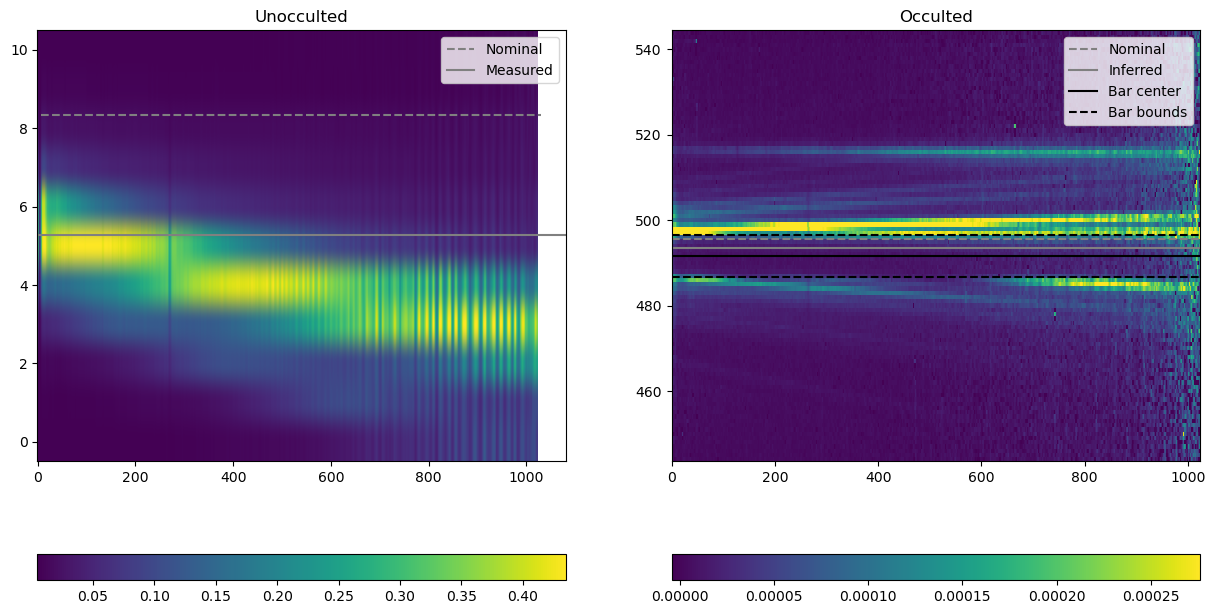

In [28]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))
# fig.suptitle(hdr['TARGNAME'] + '\n' + hdr['ROOTNAME'] + '\n' + f"POSTARG2: {hdr['POSTARG2']}")
ax = axes[0]
ax.set_title("Unocculted")
imax = ax.imshow(
    obs.unocc_trace.data, 
    **ctmisc.img_vrange(obs.unocc_trace.data),
    origin='lower'
)
fig.colorbar(imax, ax=ax, orientation='horizontal')
nominal_col, nominal_row = obs.unocc_wcs.world_to_pixel_values(
    obs.wlsol, 
    units.Quantity(0, unit='deg')
)

ax.plot(
    nominal_col,
    nominal_row - obs.unocc_trace.origin_original[1],
    c='gray', ls='--', label='Nominal'
)
ax.axhline(
    obs.unocc_row - obs.unocc_trace.origin_original[1],
    c='gray', ls='-', label='Measured'
)
ax.legend()
ax.set_aspect("auto")

ax = axes[1]
ax.set_title("Occulted")
xcoords = np.arange(-0.5, obs.wlsol.size+0.5)
ycoords = np.arange(*(obs.occ_stamp.bbox_original[0] + np.array([-0.5, 1.5])))
imax = ax.pcolormesh(
    xcoords, ycoords,
    obs.occ_stamp.data, **ctmisc.img_vrange(obs.occ_stamp.data),
)
fig.colorbar(imax, ax=ax, orientation='horizontal')
nominal_col, nominal_row = obs.occ_wcs.world_to_pixel_values(
    obs.wlsol.min(), 
    units.Quantity(0, unit='deg')
)
ax.axhline(nominal_row , c='gray', ls='--', label='Nominal')
ax.axhline(obs.occ_row, c='gray', ls='-', label='Inferred')
ax.axhline(obs.occ_bar, ls='-', c='k', label='Bar center')
bar_lb, bar_ub = obs.get_bar_bounds()
ax.axhline(bar_lb, ls='--', c='k', label='Bar bounds')
ax.axhline(bar_ub, ls='--', c='k')
ax.legend()
ax.set_aspect("auto")

## PSF Modeling and Subtraction

The module `sdi_tools.py` contains tools for managing PSF modeling and subtraction with spectral differential imaging. Our strategy is the following:

1. Scale by wavelength
   - In the original 2-d spectral images:
     - The speckles follow the 1/lambda spread of the on-axis PSF.
     - An off-axis source is dispersed straight down the row.
   - Choose a reference wavelength, `lambda_0`, and stretch each column by the factor `lambda_0/lambda_i`
     - The speckles will now be aligned with the rows
     - An off-axis PSF will follow a `1/lambda` path.
3. Interpolate under the PSF
   - Choose a row `r` for analysis in the original image, that has a real or hypothetical PSF from an off-axis companion
   - Make a copy of the image to serve as the PSF model
   - For a given width of the PSF in rows, compute the region where the upper and lower limits of the scaled PSF cross a row
   - Mask off this region, and interpolate the values of PSF
   - In the PSF model image, replace the data in the masked region with the interpolated values
5. Subtract the model from the data
6. Project the signal along the track of the scaled companion PSF back onto the original row.
   - For each column `c`, compute the nominal row coordinate of the PSF
   - Compute the distance-weighted mean of the nearest two pixels to the nominal position*
     - This choice of algorithm is semi-arbitrary
   - This is the value for the "descaled" residual for the coordinate `(x, y) = (c, r)`

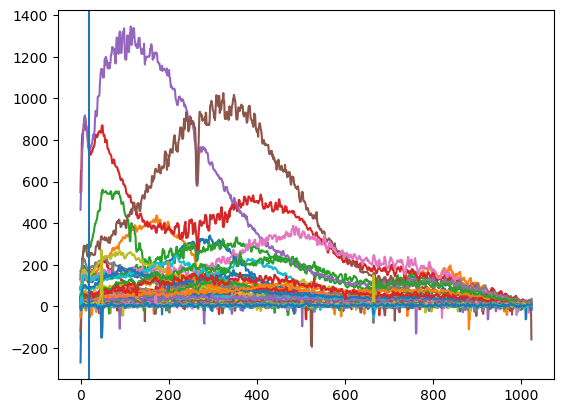

In [18]:
fig, ax = plt.subplots()
ax.plot(obs.occ_stamp.data.T);
ax.axvline(20)

I don't like how the signal spikes in the beginning and end columns so we're going to blot that out by replacing it with a constant value

In [19]:
# obs.occ_stamp.data[:, :20] = obs.occ_stamp.data[:, 20, None]
# obs.occ_stamp.data[:, -20:] = obs.occ_stamp.data[:, -21, None]

In [20]:
# fig, ax = plt.subplots()
# ax.plot(obs.occ_stamp.data.T);
# ax.axvline(10)

## SDI class

The SDI class is designed to keep the speckle modeling and subtraction organized. It has the following attributes and method (subject to change):

Attributes
- `obs` : an ObsSeq object
- `wl_pixscale` : angstroms per pixel along the spectral axis
- `ref_wl_ind` : index of the reference wavelength used to compute the scaling factors
- `scale_factors` : `lamdba[ref_wl_ind] / lambda`
- `scaled_stamp` : `obs.occ_stamp.data`, scaled by `scale_factors`. Is assigned to sdi by the `compute_scaled_stamp` method
- `psf_halfwidth`: half the width of the PSF, in rows along the spatial axis
Methods:
- `compute_scaled_stamp`: take `obs.occ_stamp.data` array and map it to a new set of coordinates where each column is stretched or compressed by a wavelength-dependent scaling factor
- `model_target_row`: pick a row in the unscaled image, figure out which rows have signal from a wavelength-scaled trace, and generate a model for those rows
- `model_scaled_row`: called by `model_target_row` on each row in the scaled image. Mask out the columns with a hypothetical trace and replace them with a model PSF
- `_compute_row_mask`: called by `model_scaled_row` to figure out which columns to mask
- `_fit_masked_data`: called by `model_scaled_row` to apply the PSF modeling function to the row data
- `subtract_target_model`: in the scaled image space, subtracts the model of the target row from the scaled data
- `descale_residual_flux`: once you have your residual signal in scaled space, project it back down to the original row


In [21]:
from coronspec_tools import sdi_tools

In [22]:
sdi = sdi_tools.SDI(
    obs,
    ref_wl_ind=-1,#int(obs.wlsol.size/2), # scaling by longer wavelengths leaves more useable pixels at small IWAs
    psf_halfwidth=4
)

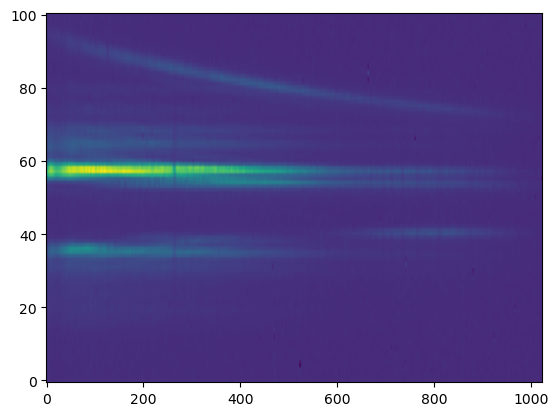

In [23]:
# Compute the scaled stamp according to the chosen reference wavelength
sdi.compute_scaled_stamp(sdi.ref_wl_ind, obs.occ_stamp.data, obs.occ_stamp_center)
# this sets sdi.scaled_stamp
plt.imshow(sdi.scaled_stamp, origin='lower', aspect='auto')

Let's examine row 71 in the stamp, the approximate position of the contaminant. We will look at the signal in row 75 of the scaled stamp.

In [24]:
target_row_ind = 72
scaled_row_ind = 75
target_row = sdi.obs.occ_stamp.data[target_row_ind]
scaled_row = sdi.scaled_stamp[scaled_row_ind]

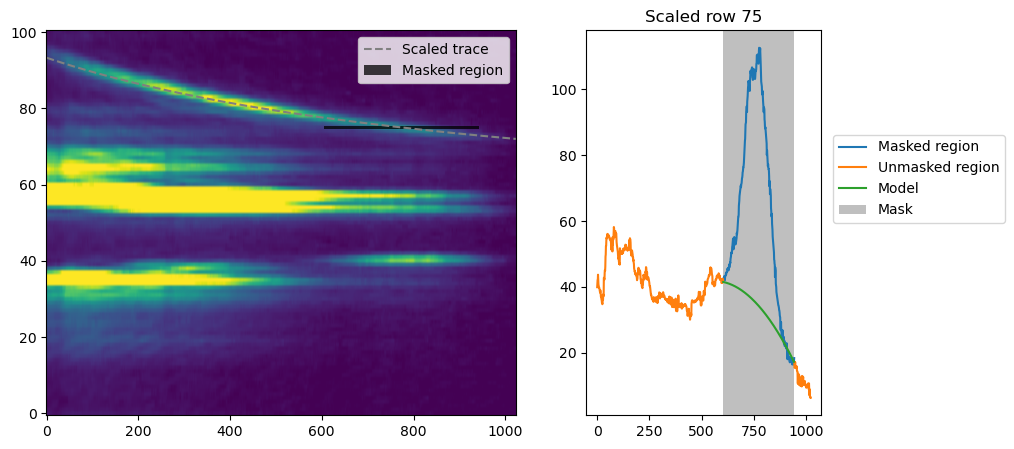

In [62]:
# Get the col, row trace in the scaled space
x, y = np.arange(obs.wlsol.size), sdi_tools.compute_scaled_psf_trace(
    target_row_ind, 
    sdi.obs.occ_stamp_center,
    sdi.scale_factors
)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), width_ratios=(2, 1))
ax = axes[0]
ax.imshow(
    sdi.scaled_stamp, 
    aspect='auto', origin='lower', **ctmisc.img_vrange(sdi.scaled_stamp, 0.05, 0.95)
)
ax.plot(x, y, c='gray', ls='--', label='Scaled trace')

# Let's show which columns we're going to mask from the row of interest
mask_lb, mask_ub = sdi._compute_row_mask(
    target_row_ind, scaled_row_ind, sdi.psf_halfwidth
)
ax.add_patch(mpl.patches.Rectangle((mask_lb, scaled_row_ind-0.5), (mask_ub-mask_lb), 1, facecolor='k', alpha=0.75, label='Masked region'))
ax.legend()


# Now we're going to show our PSF model
ax = axes[1]
ax.set_title(f"Scaled row {scaled_row_ind}")
mask = np.zeros_like(scaled_row, dtype=bool)
mask[np.floor(mask_lb).astype(int):np.ceil(mask_ub).astype(int)+1] = True
masked_row = np.ma.masked_array(scaled_row, mask=mask)

cols = np.arange(scaled_row.size)
ax.plot(cols[masked_row.mask], scaled_row[masked_row.mask], label='Masked region')
ax.plot(cols, masked_row, label='Unmasked region')

# the fit_pad parameter tunes how many columns on either side are used to fit the polynomial
model_row = sdi.model_scaled_row(
    target_row_ind, scaled_row_ind, sdi.psf_halfwidth, fit_pad=100
)
ax.plot(np.arange(model_row.size)[masked_row.mask], model_row[masked_row.mask], label='Model')

ax.axvspan(mask_lb, mask_ub, fc='gray', alpha=0.5, label='Mask')
# ax.axvline(mask_ub, c='gray', ls='--')
ax.legend(loc=(1.05, 0.5))

Plot the mask for every row that has signal

In [63]:
trace_rows = np.arange(np.floor(y.min()), np.ceil(y.max())+1, dtype=int)
trace_rows

array([72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88,
       89, 90, 91, 92, 93, 94])

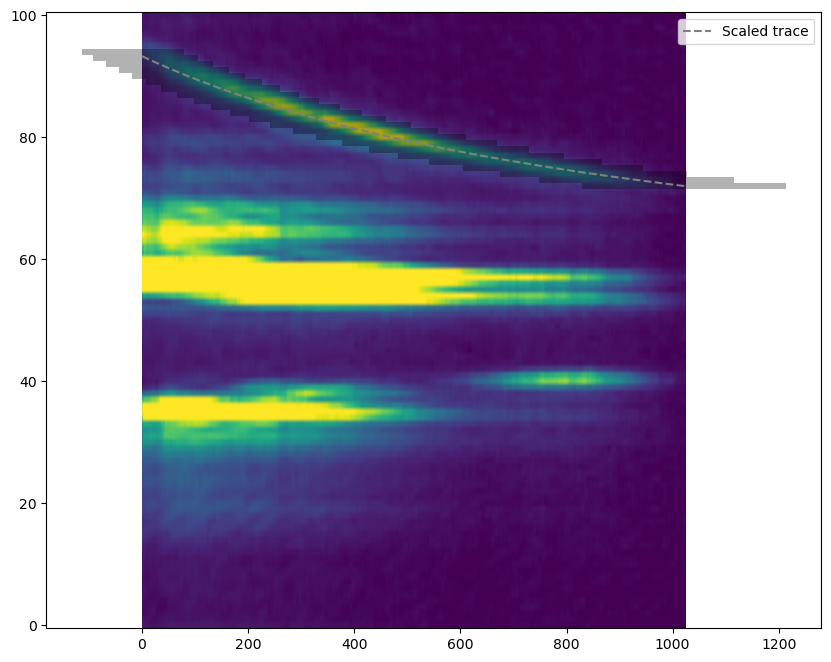

In [64]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 8))
ax.imshow(sdi.scaled_stamp, aspect='auto', origin='lower', **ctmisc.img_vrange(sdi.scaled_stamp, 0.05, 0.95), cmap='viridis')
ax.plot(x, y, c='gray', ls='--', label='Scaled trace')

for scaled_row_ind in trace_rows:
    lb, ub = sdi._compute_row_mask(target_row_ind, scaled_row_ind, sdi.psf_halfwidth)
    ax.add_patch(mpl.patches.Rectangle((lb, scaled_row_ind-0.5), (ub-lb), 1, facecolor='k', alpha=0.3))
ax.legend()


Now that we've shown all the masks, we can fit the unmasked data. Play around with the `model_scaled_row` parameters `psf_halfwidth`, `fit_poly`, and `fit_pad`.

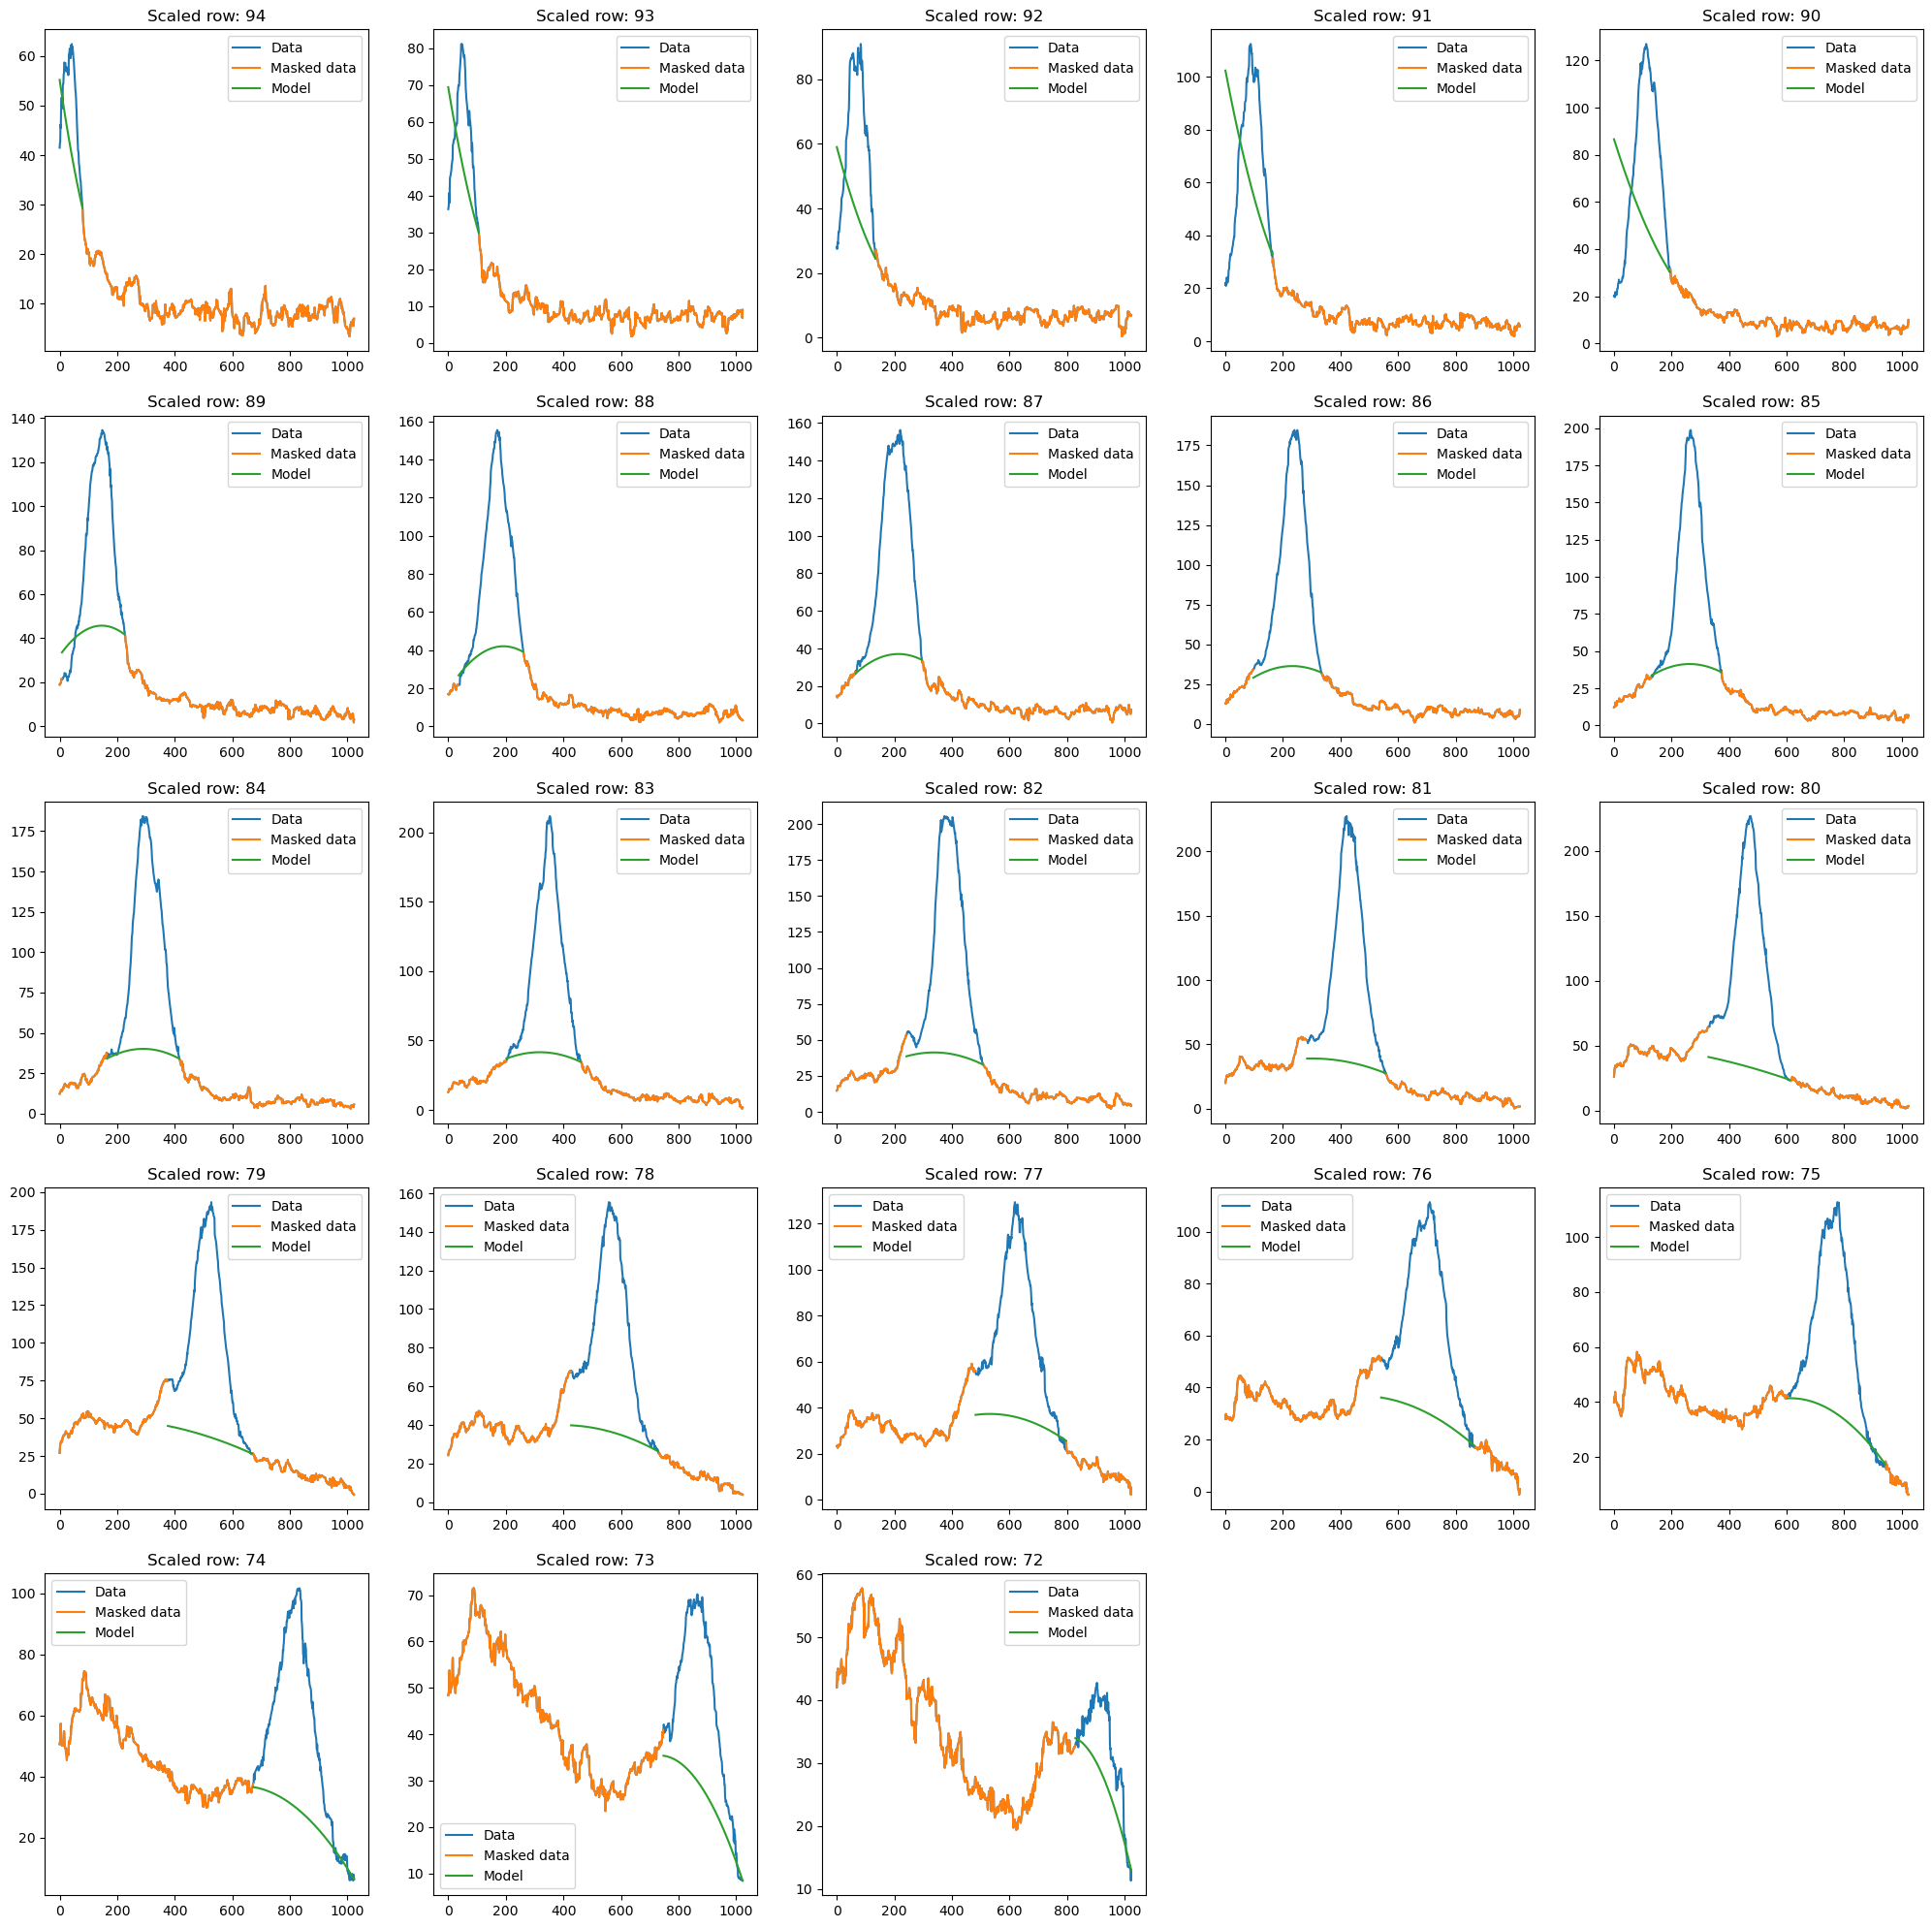

In [65]:
naxes = trace_rows.size
ncols = np.ceil(np.sqrt(naxes)).astype(int)
nrows = np.ceil(naxes/ncols).astype(int)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 5*nrows))
psf_model = sdi.scaled_stamp.copy()#np.zeros((trace_rows.size, scaled_img.shape[1]))
for i, (ax, scaled_row_ind) in enumerate(zip(axes.flat, trace_rows[::-1])):
    ax.set_title(f"Scaled row: {scaled_row_ind}")
    scaled_row = sdi.scaled_stamp[scaled_row_ind]
    mask_range = sdi._compute_row_mask(target_row_ind, scaled_row_ind, sdi.psf_halfwidth)
    mask = sdi_tools.mask_range_to_bool(mask_range, scaled_row.size)
    masked_row = np.ma.masked_array(scaled_row, mask=mask)
    model_row = sdi.model_scaled_row(
        target_row_ind, scaled_row_ind, 
        psf_halfwidth=sdi.psf_halfwidth,
        fit_poly = 2,
        fit_pad = 200,
    )
    psf_model[scaled_row_ind] = model_row
    cols = np.arange(scaled_row.size)
    ax.plot(cols, scaled_row, label='Data')
    ax.plot(cols, masked_row, label='Masked data')
    ax.plot(cols[masked_row.mask], model_row[masked_row.mask], label='Model')
    ax.legend()
for ax in axes.flat[trace_rows.size:]:
    ax.set_visible(False)

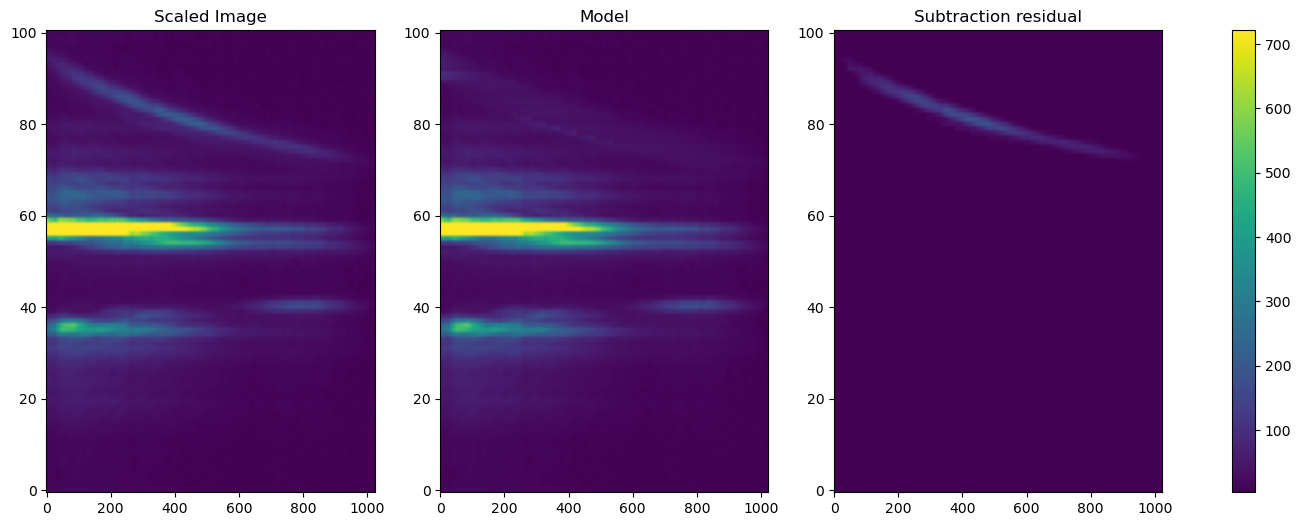

In [66]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
ax = axes[0]
ax.set_title("Scaled Image")
vrange = ctmisc.img_vrange(sdi.scaled_stamp)
imax = ax.imshow(sdi.scaled_stamp, origin='lower', aspect='auto', **vrange)

ax = axes[1]
ax.set_title("Model")
ax.imshow(psf_model, origin='lower', aspect='auto', **vrange)

ax = axes[2]
ax.set_title("Subtraction residual")
diff = sdi.scaled_stamp - psf_model
ax.imshow(diff, origin='lower', aspect='auto', **vrange)

fig.colorbar(imax, ax=axes)

OK, so that works in principle. What about a hypothetical source bellow the image?

In [67]:
target_row_ind = 30
scaled_row_ind = 25

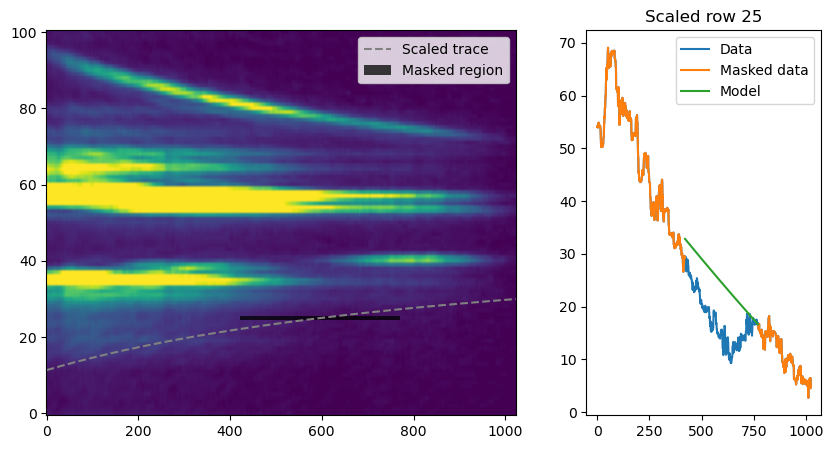

In [68]:
target_row = sdi.obs.occ_stamp.data[target_row_ind]
x, y = np.arange(obs.wlsol.size), sdi_tools.compute_scaled_psf_trace(
    target_row_ind, 
    sdi.obs.occ_stamp_center,
    sdi.scale_factors
)
scaled_row = sdi.scaled_stamp[scaled_row_ind]


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), width_ratios=(2, 1))
ax = axes[0]
ax.imshow(sdi.scaled_stamp, aspect='auto', origin='lower', **ctmisc.img_vrange(sdi.scaled_stamp, 0.05, 0.95))
ax.plot(x, y, c='gray', ls='--', label='Scaled trace')
lb, ub = sdi._compute_row_mask(target_row_ind, scaled_row_ind, sdi.psf_halfwidth)
ax.add_patch(mpl.patches.Rectangle((lb, scaled_row_ind-0.5), (ub-lb), 1, facecolor='k', alpha=0.75, label='Masked region'))
ax.legend()

ax = axes[1]
ax.set_title(f"Scaled row {scaled_row_ind}")
mask = np.zeros_like(scaled_row, dtype=bool)
mask[np.floor(lb).astype(int):np.ceil(ub).astype(int)+1] = True
masked_row = np.ma.masked_array(scaled_row, mask=mask)

ax.plot(scaled_row, label='Data')
ax.plot(masked_row, label='Masked data')

model_row = sdi.model_scaled_row(target_row_ind, scaled_row_ind, sdi.psf_halfwidth)
ax.plot(np.arange(model_row.size)[masked_row.mask], model_row[masked_row.mask], label='Model')
ax.legend()

Plot the mask for every row

In [69]:
trace_rows = np.arange(np.floor(y.min()), np.ceil(y.max())+1, dtype=int)
trace_rows

array([11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27,
       28, 29, 30])

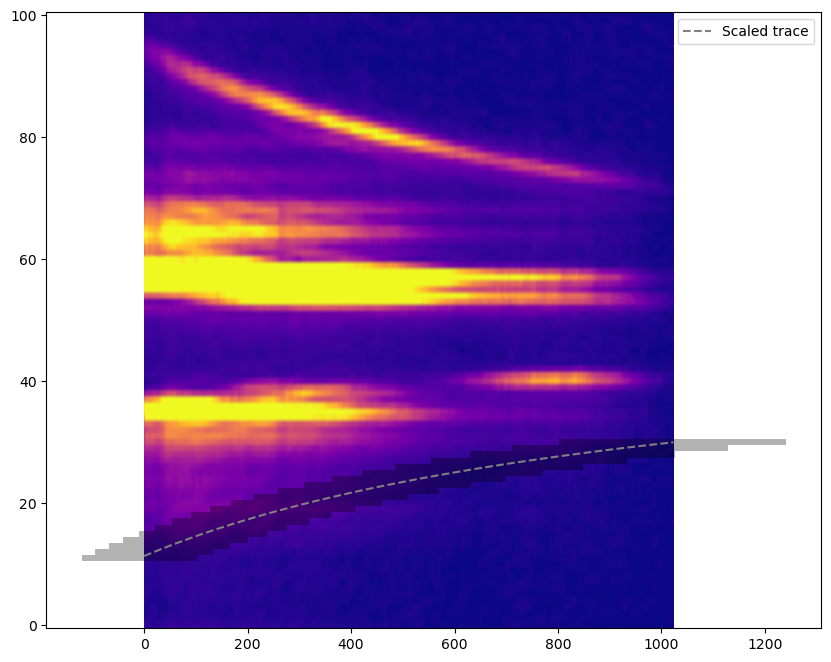

In [70]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 8))
ax.imshow(sdi.scaled_stamp, aspect='auto', origin='lower', **ctmisc.img_vrange(sdi.scaled_stamp, 0.05, 0.95), cmap='plasma')
ax.plot(x, y, c='gray', ls='--', label='Scaled trace')

for scaled_row_ind in trace_rows:
    lb, ub = sdi._compute_row_mask(target_row_ind, scaled_row_ind, sdi.psf_halfwidth)
    ax.add_patch(mpl.patches.Rectangle((lb, scaled_row_ind-0.5), (ub-lb), 1, facecolor='k', alpha=0.3))
ax.legend()


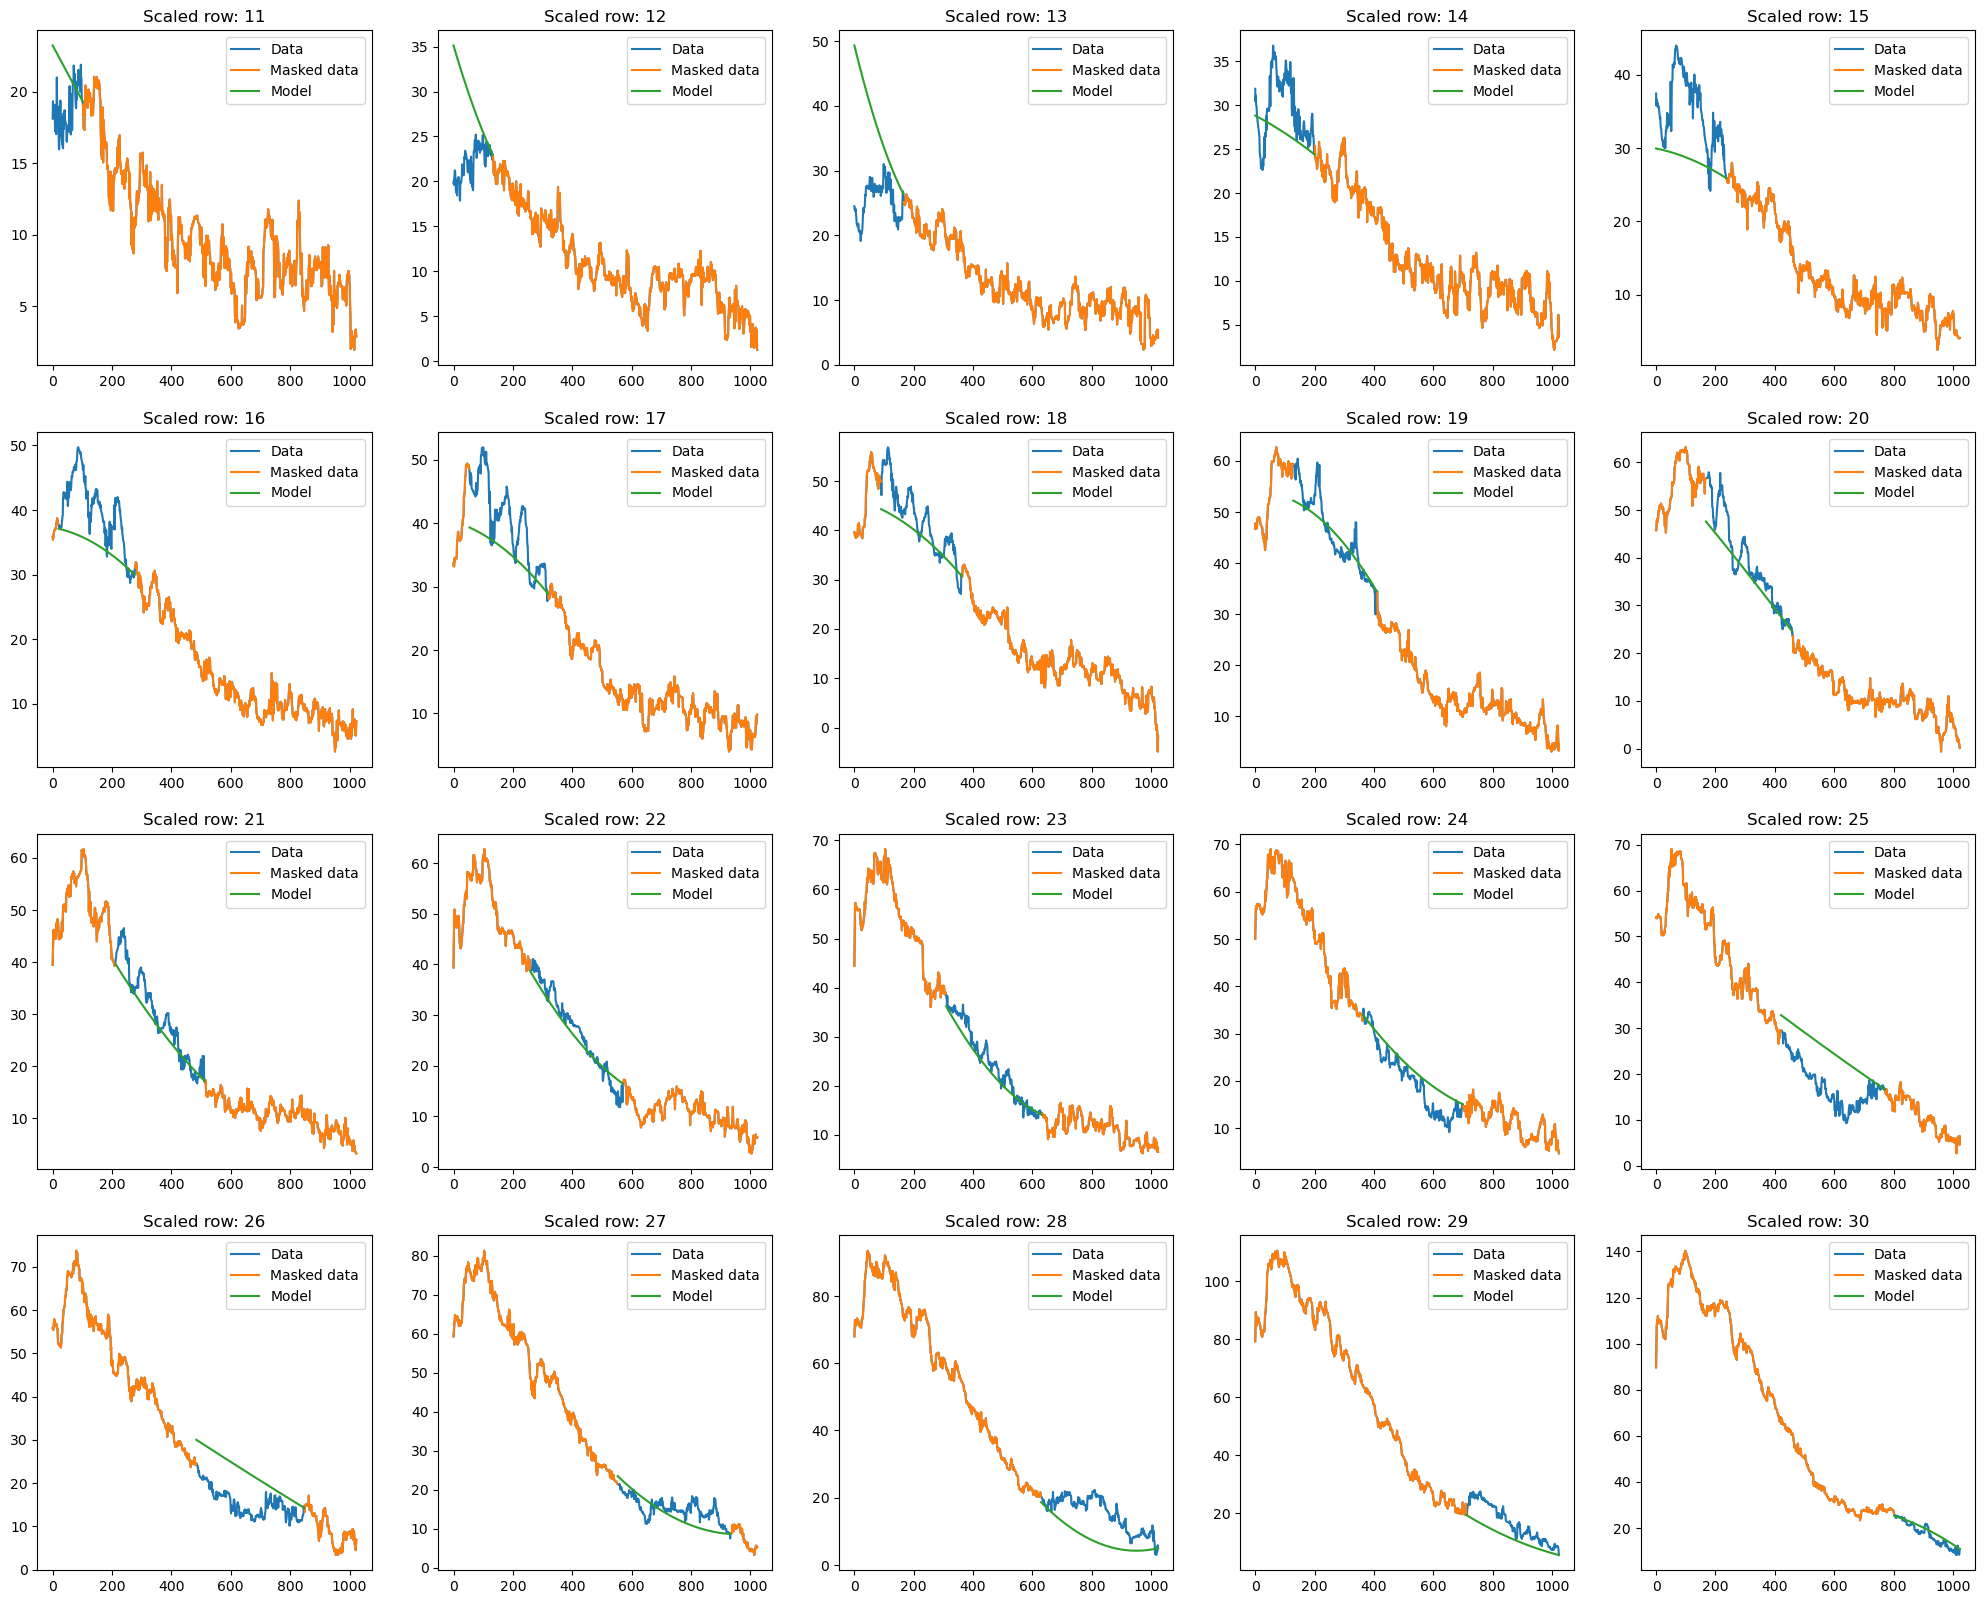

In [71]:
naxes = trace_rows.size
ncols = np.ceil(np.sqrt(naxes)).astype(int)
nrows = np.ceil(naxes/ncols).astype(int)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 5*nrows))
psf_model = sdi.scaled_stamp.copy()#np.zeros((trace_rows.size, scaled_img.shape[1]))
for i, (ax, scaled_row_ind) in enumerate(zip(axes.flat, trace_rows)):
    ax.set_title(f"Scaled row: {scaled_row_ind}")
    scaled_row = sdi.scaled_stamp[scaled_row_ind]
    mask_range = sdi._compute_row_mask(target_row_ind, scaled_row_ind, sdi.psf_halfwidth)
    mask = sdi_tools.mask_range_to_bool(mask_range, scaled_row.size)
    masked_row = np.ma.masked_array(scaled_row, mask=mask)
    model_row = sdi.model_scaled_row(target_row_ind, scaled_row_ind, sdi.psf_halfwidth, fit_pad=200, fit_poly=2)
    psf_model[scaled_row_ind] = model_row
    cols = np.arange(scaled_row.size)
    ax.plot(cols, scaled_row, label='Data')
    ax.plot(cols, masked_row, label='Masked data')
    ax.plot(cols[masked_row.mask], model_row[masked_row.mask], label='Model')
    ax.legend()
for ax in axes.flat[trace_rows.size:]:
    ax.set_visible(False)

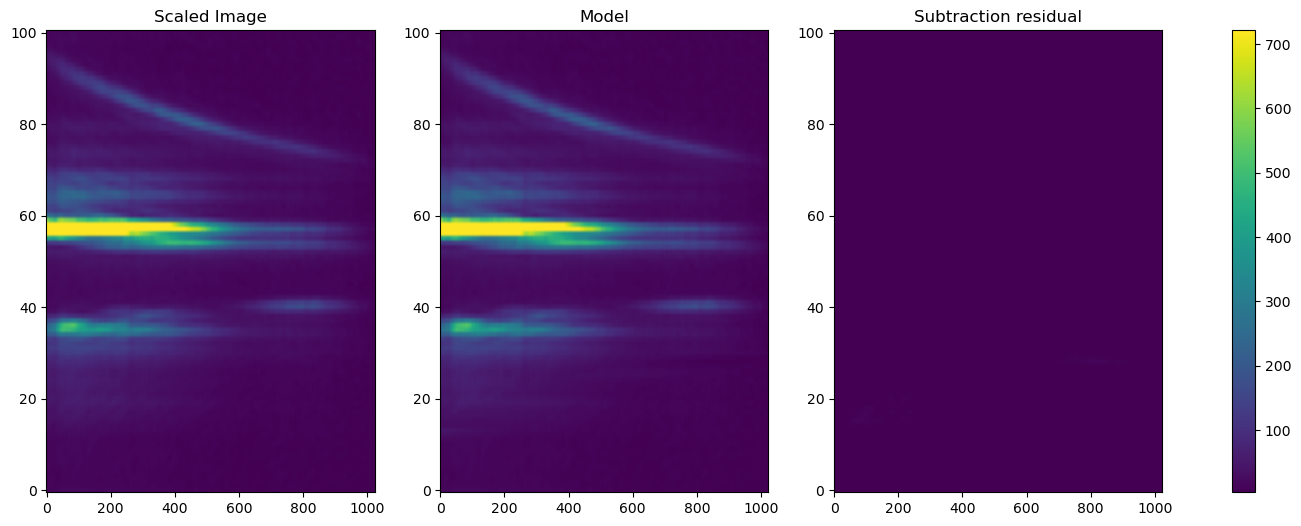

In [72]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
ax = axes[0]
ax.set_title("Scaled Image")
vrange = ctmisc.img_vrange(sdi.scaled_stamp)
imax = ax.imshow(sdi.scaled_stamp, origin='lower', aspect='auto', **vrange)

ax = axes[1]
ax.set_title("Model")
ax.imshow(psf_model, origin='lower', aspect='auto', **vrange)

ax = axes[2]
ax.set_title("Subtraction residual")
diff = sdi.scaled_stamp - psf_model
ax.imshow(diff, origin='lower', aspect='auto', **vrange)

fig.colorbar(imax, ax=axes)

The routines above are all wrapped inside the function `model_target_row`, and `subtract_target_model`.

In [73]:
# target_row_ind = 72
# model = sdi.model_target_row(target_row_ind)
# diff = sdi.subtract_target_model(target_row_ind)
# fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# ax = axes[0]
# ax.set_title("Occulted stamp")
# imax = ax.imshow(sdi.obs.occ_stamp.data, aspect='auto', origin='lower')
# fig.colorbar(imax, ax=ax, orientation='horizontal')
# ax.axhline(target_row_ind, c='gray', ls='--', alpha=0.5)

# ax = axes[1]
# ax.set_title("Model")
# imax = ax.imshow(model, aspect='auto', origin='lower', norm=mpl.colors.LogNorm())
# fig.colorbar(imax, ax=ax, orientation='horizontal')

# ax = axes[2]
# ax.set_title("Residual")
# imax = ax.imshow(diff, aspect='auto', origin='lower')
# fig.colorbar(imax, ax=ax, orientation='horizontal')

## Modeling and subtraction for the whole image

For each target row, save this model and attach it to the sdi object! Also compute the residuals, and the row indices of the trace for each column.

The function `sdi.generate_model_results_df()` assembles a pandas dataframe. Each row corresponds to a target row, given by the index. The columns are:
- 'trace': row coordinates of the trace in each column
- 'row_indices': the row indices covered by the trace
- 'scaled_stamp': the section of the scaled stamp indexed by row_indices
- 'model': the model of the scaled stamp
- 'residual': scaled_stamp - model


In [74]:
sdi.generate_model_results_df(20, 80)

trace               [93.30074529405658, 93.2601541513141, 93.21963...
row_indices         [72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 8...
scaled_stamp        [[42.007824, 43.327557, 44.556595, 43.148827, ...
scaled_stamp_unc    [[5.9630795, 5.9778233, 5.9989195, 5.9822927, ...
stamp_mask          [[True, True, True, True, True, True, True, Tr...
model               [[42.0078239440918, 43.32755661010742, 44.5565...
residual            [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
Name: 72, dtype: object

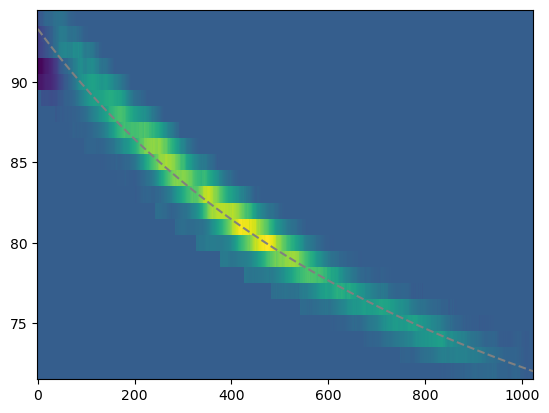

In [75]:
row = sdi.model_results.loc[72]
# trace = row['trace']
fig, ax = plt.subplots()
xcoords = np.arange(-0.5, row['residual'].shape[1]+0.5)
ycoords = np.arange(row['row_indices'].min()-0.5, row['row_indices'].max()+1.5)
ax.pcolormesh(
    xcoords, ycoords,
    row['residual']
)
ax.plot(row['trace'], c='gray', ls='--')

# Some models have rows that are NaN'd. Why?

In [76]:
# These target rows have NaNs somewhere in their corresponding scaled models
target_nans = sdi.model_results['model'].apply(lambda el: np.any(np.isnan(el)))
target_nans[target_nans]

44    True
45    True
46    True
47    True
48    True
49    True
50    True
51    True
52    True
53    True
54    True
55    True
Name: model, dtype: bool

These are all very close to the star position. Maybe it's because the masks are very large, and there are no pixels available to fit?

In [77]:
# let's look at Target Row 44 as an example
target_row_ind = 44
sdi._get_masks_for_target_row(target_row_ind)

38    (-431.3134282485835, 308.77751227291037)
39     (-370.7327581078133, 439.1087023505321)
40    (-297.54496146628287, 596.5624349237244)
41    (-207.35758869710497, 790.5884764922307)
42    (-93.46957738839751, 1035.6032644591962)
43     (54.87490719108109, 1354.7465352709746)
44     (256.1000009490326, 1787.6553473064662)
dtype: object

In [78]:
x, y = np.arange(obs.wlsol.size), sdi_tools.compute_scaled_psf_trace(
    target_row_ind, 
    sdi.obs.occ_stamp_center,
    sdi.scale_factors
)

In [79]:
sdi.model_results.loc[target_row_ind, 'row_indices'][np.isnan(sdi.model_results.loc[target_row_ind, 'model']).all(axis=1)]
# np.isnan(sdi.model_results.loc[target_row_ind, 'model']).all(axis=1)

array([42])

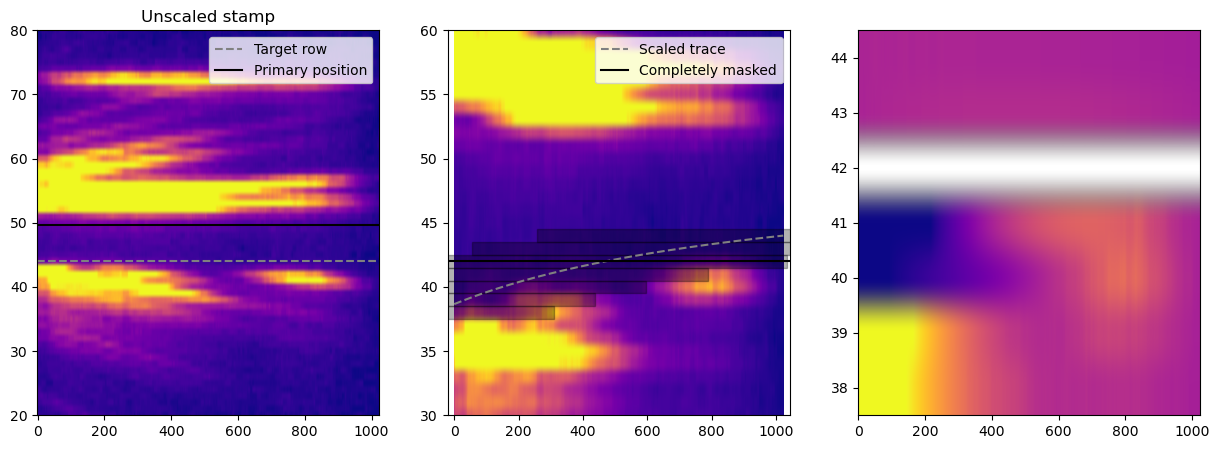

In [80]:
trace_rows = sdi.check_trace_rows(sdi.model_results.loc[target_row_ind, 'trace'])

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5), sharey=False)
ax = axes[0]
ax.set_title("Unscaled stamp")
ax.imshow(sdi.obs.occ_stamp.data, aspect='auto', origin='lower', **ctmisc.img_vrange(sdi.obs.occ_stamp.data, 0.05, 0.95), cmap='plasma')
ax.axhline(target_row_ind, c='gray', ls='--', label='Target row')
ax.axhline(sdi.obs.occ_stamp_center, c='k', ls='-', label='Primary position')
ax.legend()
ax.set_ylim(20, 80)

ax = axes[1]
ax.imshow(sdi.scaled_stamp, aspect='auto', origin='lower', **ctmisc.img_vrange(sdi.scaled_stamp, 0.05, 0.95), cmap='plasma')
ax.plot(x, y, c='gray', ls='--', label='Scaled trace')


for scaled_row_ind in trace_rows:
    lb, ub = sdi._compute_row_mask(target_row_ind, scaled_row_ind, sdi.psf_halfwidth)
    ax.add_patch(mpl.patches.Rectangle((lb, scaled_row_ind-0.5), (ub-lb), 1, facecolor='k', alpha=0.3, ec='k', lw=1))
ax.set_ylim(30, 60)
ax.axhline(
    # sdi.target_row_model_rows[target_row_ind][np.isnan(sdi.target_row_models[target_row_ind]).all(axis=1)],
    sdi.model_results.loc[target_row_ind, 'row_indices'][np.isnan(sdi.model_results.loc[target_row_ind, 'model']).all(axis=1)],
    ls='-', c='k', label='Completely masked'
)
ax.legend()
ax.set_xlim(-20, 1023+20)
ax = axes[2]
ax.imshow(
    sdi.model_results.loc[target_row_ind, 'model'],
    aspect='auto', origin='lower', 
    **ctmisc.img_vrange(sdi.model_results.loc[target_row_ind, 'model'], 0.05, 0.95), cmap='plasma'
)
ax.set_yticks(
    np.arange(sdi.model_results.loc[target_row_ind, 'row_indices'].size), 
    sdi.model_results.loc[target_row_ind, 'row_indices']
);

Yep, it seems that the NaNs appear when the masks don't leave any pixels available for fitting./

## Reconstruct the signal for each residual

The function that does this is called `descale_trace`. Right now, it is pretty simple. It computes the position of the trace in the residual stamp. For each column, it takes the two pixels above and below the trace and computes the distance-weighted mean. That value is the residual signal for the column.

In [81]:
sdi.model_results['signal'] = sdi.model_results.apply(
    lambda row: sdi.descale_trace(row['residual'], row['trace'], row['row_indices'][[0, -1]]),
    axis=1
)

/Users/jaguilar/Projects/miniconda3/envs/stiscoron/lib/python3.13/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/jaguilar/Projects/Research/hst17092-stis_coron/coronspec_tools/src/coronspec_tools/sdi_tools.py:102: RuntimeWarning: invalid value encountered in scalar divide
  signal[c] = np.sum(scaled_img[[r_lo,r_hi], c]*weights) / np.sum(weights)


Combine the target row signals into a single image

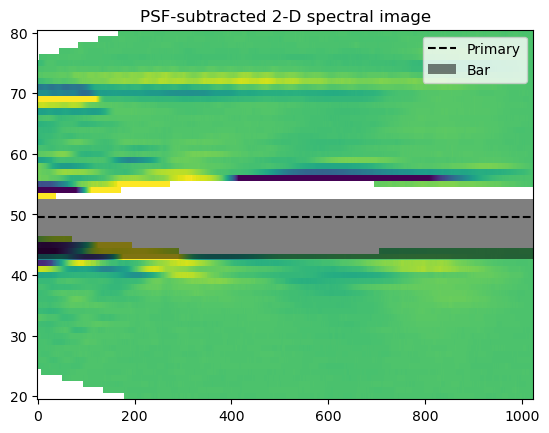

In [82]:
signal_img = np.stack(sdi.model_results['signal'])
xcoords = np.arange(-0.5, signal_img.shape[1]+0.5)
ycoords = np.arange(sdi.model_results.index[0]-0.5, sdi.model_results.index[-1]+1.5)
fig, ax = plt.subplots()
ax.set_title("PSF-subtracted 2-D spectral image")
ax.pcolormesh(xcoords, ycoords, signal_img, **ctmisc.img_vrange(signal_img))
ax.axhline(obs.occ_stamp_center, c='k', ls='--', label='Primary')
# ax.axhline(obs.occ_bar - obs.occ_stamp.origin_original[1], c='k', label='Bar')
bar_bounds = np.array(obs.get_bar_bounds()) - obs.occ_stamp.origin_original[1]
bar = mpl.patches.Rectangle((0, bar_bounds[0]), signal_img.shape[1], bar_bounds[1]-bar_bounds[0], fc='k', alpha=0.5, label='Bar')
ax.add_patch(bar)
ax.legend()

It is interesting to see pretty clearly here that the NaN region is centered on the primary, not the bar.

Let's make a hacky SNR metric - let's say, divide each column by the sigma-clipped 1-sigma

In [83]:
# first, mask out rows under the bar
bar_bounds = np.array(obs.get_bar_bounds()) - obs.occ_stamp.origin_original[1]
bar_mask = (sdi.model_results.index > bar_bounds[0]) & (sdi.model_results.index < bar_bounds[1])

In [84]:
from astropy.stats import sigma_clipping

In [85]:
col_mean, _, col_sigma = sigma_clipping.sigma_clipped_stats(signal_img[~bar_mask], axis=0)
snr_img = (signal_img-col_mean)/col_sigma
snr_img[bar_mask] = np.nan

In [86]:
snr_by_row = np.nanmedian(snr_img, axis=1)
detection_rows = sdi.model_results.index[snr_by_row > 5]
detection_rows

/Users/jaguilar/Projects/miniconda3/envs/stiscoron/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Index([53], dtype='int64')

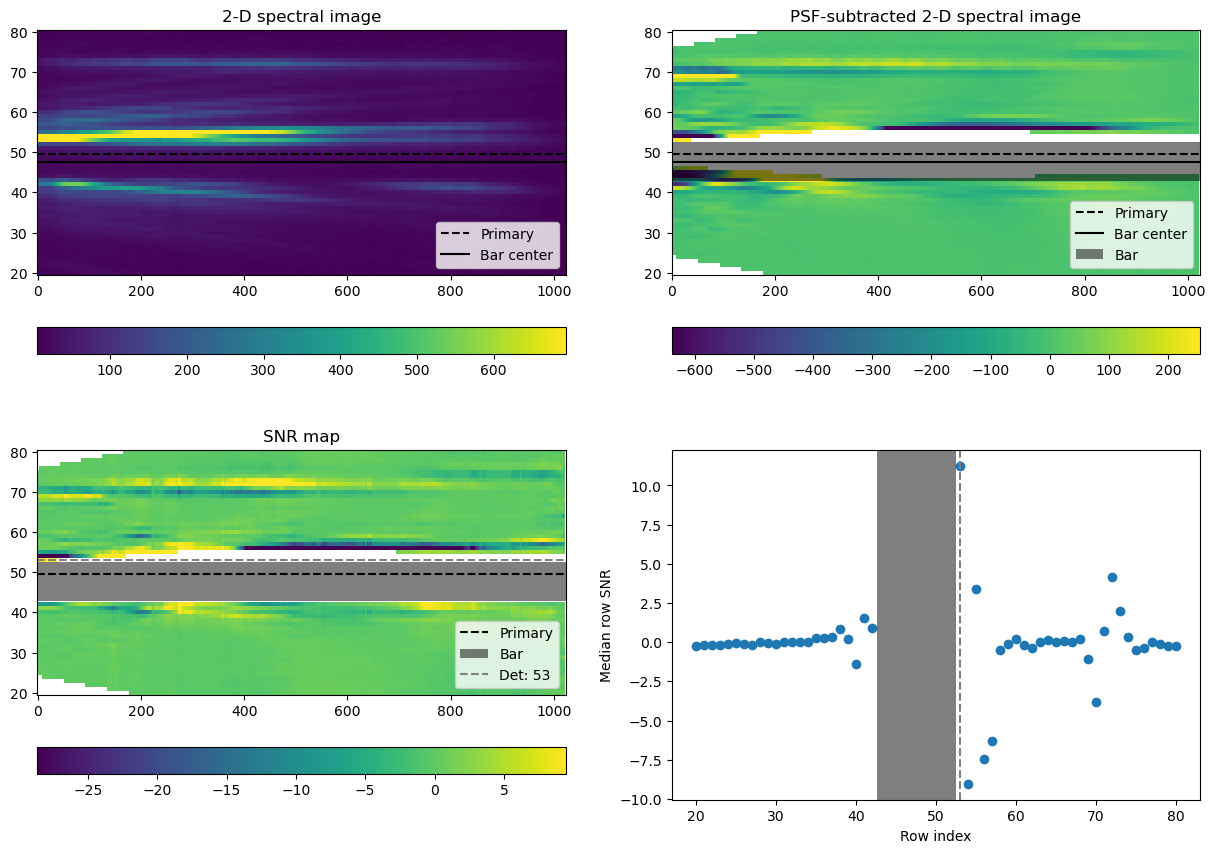

In [87]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
ax = axes[0, 0]
ax.set_title("2-D spectral image")
imax = ax.pcolormesh(xcoords, ycoords, obs.occ_stamp.data[sdi.model_results.index], **ctmisc.img_vrange( obs.occ_stamp.data[sdi.model_results.index]))
ax.axhline(obs.occ_stamp_center, c='k', ls='--', label='Primary')
ax.axhline(obs.occ_bar - obs.occ_stamp.origin_original[1], c='k', label='Bar center')
# bar_bounds = np.array(obs.get_bar_bounds()) - obs.occ_stamp.origin_original[1]
# bar = mpl.patches.Rectangle((0, bar_bounds[0]), signal_img.shape[1], bar_bounds[1]-bar_bounds[0], fc='k', alpha=0.5, label='Bar')
# ax.add_patch(bar)
ax.legend(loc='lower right')
fig.colorbar(imax, ax=ax, orientation='horizontal')

ax = axes[0, 1]
ax.set_title("PSF-subtracted 2-D spectral image")
imax = ax.pcolormesh(xcoords, ycoords, signal_img, **ctmisc.img_vrange(signal_img))
ax.axhline(obs.occ_stamp_center, c='k', ls='--', label='Primary')
ax.axhline(obs.occ_bar - obs.occ_stamp.origin_original[1], c='k', label='Bar center')
bar_bounds = np.array(obs.get_bar_bounds()) - obs.occ_stamp.origin_original[1]
bar = mpl.patches.Rectangle((0, bar_bounds[0]), signal_img.shape[1], bar_bounds[1]-bar_bounds[0], fc='k', alpha=0.5, label='Bar')
ax.add_patch(bar)
ax.legend(loc='lower right')
fig.colorbar(imax, ax=ax, orientation='horizontal')

ax = axes[1, 0]
ax.set_title("SNR map")
imax = ax.pcolormesh(xcoords, ycoords, snr_img, **ctmisc.img_vrange(snr_img))
ax.axhline(obs.occ_stamp_center, c='k', ls='--', label='Primary')
# ax.axhline(obs.occ_bar - obs.occ_stamp.origin_original[1], c='k', label='Bar')
bar_bounds = np.array(obs.get_bar_bounds()) - obs.occ_stamp.origin_original[1]
bar = mpl.patches.Rectangle((0, bar_bounds[0]), signal_img.shape[1], bar_bounds[1]-bar_bounds[0], fc='k', alpha=0.5, label='Bar')
ax.add_patch(bar)
for dr in detection_rows:
    ax.axhline(dr, c='gray', ls='--', label=f'Det: {dr}')
ax.legend(loc='lower right')
fig.colorbar(imax, ax=ax, orientation='horizontal')



ax = axes[1, 1]
ax.set_xlabel("Row index")
ax.set_ylabel("Median row SNR")
ax.scatter(sdi.model_results.index, np.nanmedian(snr_img, axis=1))
ax.axvspan(*bar_bounds, alpha=0.5, fc='k')
for dr in detection_rows:
    ax.axvline(dr, c='gray', ls='--')


## Hacky signal conversion to flux

Here we convert from a row to a flux by multiplying the residual by the throughput. In real life, you would replace the FLT or CRJ image with your PSF-subtracted residual image, and run that through CALSTIS.

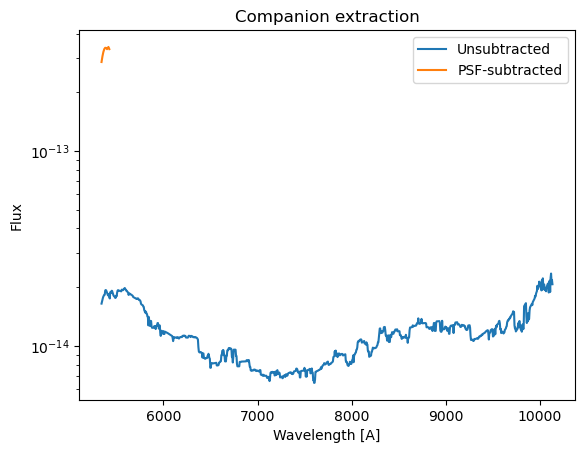

In [88]:
signal_row = np.arange(signal_img.shape[0])[sdi.model_results.index == detection_rows[0]][0]

plt.plot(obs.wlsol[20:-20].to("Angstrom"), sdi.obs.contrast_counts2flux(sdi.obs.occ_stamp.data[signal_row])[20:-20], label='Unsubtracted')
plt.plot(obs.wlsol[20:-20].to("Angstrom"), sdi.obs.contrast_counts2flux(signal_img[signal_row])[20:-20], label='PSF-subtracted')
plt.ylabel('Flux')
plt.xlabel("Wavelength [A]")
plt.title("Companion extraction")
plt.legend()
plt.yscale("log")